In [ ]:
reset

In [3]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import collections
import pandas as pd
import xarray as xr
import cf_xarray as cf
import cftime
xr.set_options(keep_attrs=True)
import netCDF4 as nc
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
import metpy.calc as mp
from metpy.units import units
from scipy.stats import ttest_ind, ttest_rel
from datetime import datetime

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.offsetbox import AnchoredText
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import cmocean.cm as cmo
import seaborn as sns

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from map_plot_tools import *
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *

In [4]:
def windSpd(u,v):
   windSpd=np.sqrt(u**2 + v**2)
   return windSpd

def SeaLevelPressure(p,z,t):
    # constants
    g = 9.80665  # m/s²
    Rd = 287.05  # J/kg/K
    lapse_rate = 0.0065  # K/m

    # convert p from hPa to Pa
    # ---> FLOR data already in Pa
    #ps = p * 100
    ps = p
    Tmean = t + (lapse_rate * z/2)

    # calculate sea level pressure, convert to hPa
    slp = ps * np.exp(g * z / (Rd * Tmean))
    slp_hpa = slp / 100

    return slp_hpa

# LOAD DATA

In [5]:
### +++ DATA PATHS +++ ###

# product keys
keys=['obs','flor']
obs_prods=['merra2']
flor_runs=['ctrl','hicam','hitopo']
flor_simNames=['ctrl','cam','hitopo']

# store file paths in dictionary
dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar' # top level data directory
opath='/home/dmkumar/JupyterLinks/notebooks/topo_heat/figs'
files={ 'obs'  : { 'merra2' : {} },
        'flor' : { 'ctrl'   : {},
                   'hicam'  : {}, 
                   'hitopo' : {} }
      }

for key in ['obs']:
    for i,run in enumerate(obs_prods):
        files[key][run]['u925'] = f'{dpath0}/obs_data/merra2/merra2.U.1980-2022.monthly.nc' 
        files[key][run]['v925'] = f'{dpath0}/obs_data/merra2/merra2.V.1980-2022.monthly.nc' 
        files[key][run]['slp'] = f'{dpath0}/obs_data/merra2/merra2.SLP.1980-2022.monthly.nc' 

for key in ['flor']:
    for i,run in enumerate(flor_runs):
        simName=flor_simNames[i]
        for fvarn in ['u925','v925','slp']: #'ps','t_ref']:
            files[key][run][fvarn] = f'{dpath0}/FLOR/{run}/pi/flor.{simName}.{fvarn}.monthly.nc' 
        #for fvarn in ['zsurf']:
        #    files[key][run][fvarn] = f'{dpath0}/FLOR/{run}/pi/flor.{simName}.{fvarn}.nc' 

for key in ['topo']:
    files[key] = {}
    files[key]['etopo'] = f'{dpath0}/topo_files/obs.etopo5.zsurf.nc'
    files[key]['ctrl'] = f'{dpath0}/topo_files/flor.ctrl.zsurf.nc'
    files[key]['hicam'] = f'{dpath0}/topo_files/flor.cam.zsurf.nc'
    files[key]['hitopo'] = f'{dpath0}/topo_files/flor.hitopo.zsurf.nc'

In [6]:
### +++ ORGANIZE DATA +++ ###

# pressure level
plev = 925
# time bounds
n_years=50
n_keep_days=-1 * (n_years * 365) # number of time steps to keep in days
n_keep_mons=-1 * (n_years * 12)  # number of time steps to keep in months

# initialize dictionaries
dat = { 'obs'  : { 'merra2' : {} },
        'flor' : { 'ctrl'   : {},
                   'hicam'  : {}, 
                   'hitopo' : {} }
      }

print('Working on...')
for key in ['obs']:
    varns=['u925','v925']
    print(f'{key}')
    for run in obs_prods:
        for i,ovarn in enumerate(['U','V']):
            varn=varns[i]
            ds = xr.open_dataset(files[key][run][varn], chunks={'time':12})[ovarn].sel(lev=plev) # select specific pressure level
            ds_flip = lonFlip(ds) #longitude_flip(ds) # switch lons from -180:180 to 0:360
            dat[key][run][varn] = ds_flip
            del ds
            del ds_flip
        # calculate wind speed from components
        for varn in ['spd']:
            dat[key][run][varn] = windSpd(dat[key][run]['u925'],dat[key][run]['v925'])
        for ovarn in ['SLP']:
            varn='slp'
            ds = xr.open_dataset(files[key][run][varn])[ovarn] / 100 # convert from Pa to hPa
            ds_flip = lonFlip(ds) #longitude_flip(ds) # switch lons from -180:180 to 0:360
            dat[key][run][varn] = ds_flip
            del ds
            del ds_flip
        # calculate slp zonal anomalies
        for varn in ['slpa']:
            slp_gm = latitude_weighted_mean(dat[key][run]['slp'])
            dat[key][run][varn] = dat[key][run]['slp']-slp_gm # anomaly relative to lat-weighted global mean
            del slp_gm
            #dat[key][run][varn] = dat[key][run]['slp']-dat[key][run]['slp'].mean(dim='lon') # anomaly relative to zonal mean

for key in ['flor']:
    print(f'{key}')
    for run in flor_runs:
        print(f'...{run}')
        for i,varn in enumerate(['u925','v925','slp']):
            ds = xr.open_dataset(files[key][run][varn], chunks={'time':12})[varn][n_keep_mons:,:,:] # keep only last 50 years  #decode_times=True, use_cftime=True, 
            # update coordinate names to match merra2
            if varn in ['u925','v925']:
                ds = ds.rename({'grid_xt':'lon','grid_yt':'lat'}) 
            # fix units for metpy
            ds['lat'].attrs['units'] = 'degrees_north'
            ds['lon'].attrs['units'] = 'degrees_east'
            dat[key][run][varn] = ds
            del ds
        # calculate slp anomalies
        for varn in ['slpa']:
            slp_gm = lat_weighted_mean(dat[key][run]['slp'], lat_name='lat', lon_name='lon')
            dat[key][run][varn] = dat[key][run]['slp']-slp_gm # anomaly relative to lat-weighted global mean
            del slp_gm
            #dat[key][run][varn] = dat[key][run]['slp']-dat[key][run]['slp'].mean(dim='lon') # anomaly relative to zonal mean
        # calculate wind speed from components
        for varn in ['spd']:
            dat[key][run][varn] = windSpd(dat[key][run]['u925'],dat[key][run]['v925'])
        """
        # calculate sea level pressure
        for varn in ['slp']:
            # keep only last 50 years, update coordinate names to match merra2
            psurf = xr.open_dataset(files[key][run]['ps'])['ps'][n_keep_mons:,:,:].rename({'grid_xt':'lon','grid_yt':'lat'})
            zsurf = xr.open_dataset(files[key][run]['zsurf'])['ZSURF'][:,:].rename({'GRID_XT':'lon','GRID_YT':'lat'})
            tsurf = xr.open_dataset(files[key][run]['t_ref'])['t_ref'][n_keep_mons:,:,:].rename({'grid_xt':'lon','grid_yt':'lat'})
            dat[key][run][varn] = SeaLevelPressure(psurf, zsurf, tsurf) #mp.altimeter_to_sea_level_pressure(psurf, zsurf, tsurf)
        """
print('Done.')

topo = {}
print('Loading surface height data.')
for key in ['topo']:
    for case in ['etopo']:
        ds = xr.open_dataset(files[key][case]).ROSE.rename({'ETOPO05_X':'lon', 'ETOPO05_Y':'lat'})
        topo[case] = ds.where(ds>0, np.nan)
        del ds
    for case in ['ctrl', 'hicam', 'hitopo']:
        ds = xr.open_dataset(files[key][case]).ZSURF.rename({'GRID_XT':'lon', 'GRID_YT':'lat'})
        topo[case] = ds.where(ds>0, np.nan)
        del ds
print('Done.')

Working on...
obs
flor
...ctrl
...hicam
...hitopo
Done.
Loading surface height data.
Done.


In [7]:
### +++ CALCULATE TIME-MEANS +++ ###
season='JAS'
mons=[7,8,9]
varns=['u925','v925','spd','slp','slpa']

jas_mean = { 'obs' : { 'merra2':{} },
             'flor': { 'ctrl':{}, 'hicam':{}, 'hitopo':{} } }
ann_jas_mean = { 'obs' : { 'merra2':{} },
                 'flor': { 'ctrl':{}, 'hicam':{}, 'hitopo':{} } }

print('Calculating seasonal means for...')
for key in ['obs']:
    print(f'{key}')
    for run in obs_prods:
        for varn in varns:
            # seasonal mean for whole timeseries
            custom_seasons = xr.where(dat[key][run][varn]['time'].dt.month.isin(mons), season, 'Other')
            jas_mean[key][run][varn] = dat[key][run][varn].groupby(custom_seasons).mean('time').rename({'month':'season'}).sel(season=season)
            # seasonal mean by year
            ann_jas_mean[key][run][varn] = dat[key][run][varn].sel(time=dat[key][run][varn]['time'].dt.month.isin(mons)).groupby('time.year').mean(dim='time')
      
for key in ['flor']:
    print(f'{key}')
    for run in flor_runs:
        print(f'{run}')
        for varn in varns:
            # seasonal mean for whole timeseries
            custom_seasons = xr.where(dat[key][run][varn]['time'].dt.month.isin(mons), season, 'Other')
            jas_mean[key][run][varn] = dat[key][run][varn].groupby(custom_seasons).mean('time').rename({'month':'season'}).sel(season=season)
            # seasonal mean by year
            ann_jas_mean[key][run][varn] = dat[key][run][varn].sel(time=dat[key][run][varn]['time'].dt.month.isin(mons)).groupby('time.year').mean(dim='time')

print('Done.')

Calculating seasonal means for...
obs
flor
ctrl
hicam
hitopo
Done.


In [8]:
### +++ COMPARING ALL MODEL RUNS TO OBS. +++ ###

## initialize dictionaries
# for re-gridded obs data
jas_mean_regrid = { 'obs_flor' : {} }
ann_jas_mean_regrid = { 'obs_flor' : {} }
# for significance testing results
obs_diff      = { 'flor' : { 'ctrl':{}, 'hicam':{}, 'hitopo':{} } }
obs_diff_mask = { 'flor' : { 'ctrl':{}, 'hicam':{}, 'hitopo':{} } }
obs_ptvals    = { 'flor' : { 'ctrl':{}, 'hicam':{}, 'hitopo':{} } }

# First, need to put obs data on same grid as model output
regrid_keys = ['obs_flor']

print('Re-gridding obs.')
for i,key in enumerate(['flor']):
    lats=dat[key]['ctrl']['spd'].lat
    lons=dat[key]['ctrl']['spd'].lon
    regrid_key=regrid_keys[i]
    for varn in varns:
        # interpolate obs to CM2.5-FLOR grid
        jas_mean_regrid[regrid_key][varn] = jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')
        ann_jas_mean_regrid[regrid_key][varn] = ann_jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')
print('Done.\n')

# Determine statistical significance of obs-model differences based on students t-test
print('Significance testing for:')
for key in obs_diff.keys():
    print(f'{key}')
    for run in flor_runs:
        print(f'...{run}')
        for varn in varns:
            diff_, diff_mask_, ptvals_ = sigtest2n(ann_jas_mean_regrid['obs_flor'][varn], ann_jas_mean[key][run][varn], 
                                                   jas_mean_regrid['obs_flor'][varn], jas_mean[key][run][varn])
            obs_diff[key][run][varn] = diff_
            obs_diff_mask[key][run][varn] = diff_mask_
            obs_ptvals[key][run][varn] = ptvals_
print('Done.')

Re-gridding obs.
Done.

Significance testing for:
flor
...ctrl
...hicam
...hitopo
Done.


In [9]:
### +++ WIND SIGNIFICANCE +++ ###
obs_usig = { 'flor' : { 'hicam'  : {}, 
                        'hitopo' : {} }
             }
obs_vsig = { 'flor' : { 'hicam'  : {}, 
                        'hitopo' : {} }
             }

for key in obs_usig.keys():
    if key=='flor':
        for run in flor_runs:
            obs_usig[key][run] = np.where((obs_diff_mask[key][run]['u925'].mask==False) &
                                          (obs_diff_mask[key][run]['v925'].mask==False),
                                          obs_diff_mask[key][run]['u925'].data, np.nan)
            obs_vsig[key][run] = np.where((obs_diff_mask[key][run]['u925'].mask==False) &
                                          (obs_diff_mask[key][run]['v925'].mask==False),
                                          obs_diff_mask[key][run]['v925'].data, np.nan)

In [10]:
### +++ COMPARING ALL MODEL RUNS TO MODEL CTRL. +++ ###

# initialize dictionaries
model_diff      = { 'flor' : { 'hicam':{}, 'hitopo':{} } }
model_diff_mask = { 'flor' : { 'hicam':{}, 'hitopo':{} } }
model_ptvals    = { 'flor' : { 'hicam':{}, 'hitopo':{} } }

# names of modified topography runs
flor_mod_runs=['hicam', 'hitopo']

print('Significance testing for:')
for key in model_diff.keys():
    print(f'{key}')
    for run in flor_mod_runs:
        print(f'...{run}')
        for varn in varns:
            # calculate significance of model - ctrl difference
            diff_, diff_mask_, ptvals_ = sigtest2n(ann_jas_mean[key][run][varn], ann_jas_mean[key]['ctrl'][varn],
                                                   jas_mean[key][run][varn], jas_mean[key]['ctrl'][varn])
            model_diff[key][run][varn] = diff_
            model_diff_mask[key][run][varn] = diff_mask_
            model_ptvals[key][run][varn] = ptvals_

print('Done.')

Significance testing for:
flor
...hicam
...hitopo
Done.


In [11]:
### +++ MODEL WIND SIGNIFICANCE +++ ###

model_usig = { 'flor' : { 'hicam'  : {}, 
                          'hitopo' : {} }
             }
model_vsig = { 'flor' : { 'hicam'  : {}, 
                          'hitopo' : {} }
             }

for key in model_usig.keys():
    for run in flor_mod_runs:
        model_usig[key][run] = np.where((model_diff_mask[key][run]['u925'].mask==False) &
                                        (model_diff_mask[key][run]['v925'].mask==False),
                                        model_diff_mask[key][run]['u925'].data, np.nan)
        model_vsig[key][run] = np.where((model_diff_mask[key][run]['u925'].mask==False) &
                                        (model_diff_mask[key][run]['v925'].mask==False),
                                        model_diff_mask[key][run]['v925'].data, np.nan)


In [12]:
### +++ BIAS IMPROVEMENT +++ ###

bias_change        = { 'flor' : { 'hicam':{}, 'hitopo':{} } }
bias_change_masked = { 'flor' : { 'hicam':{}, 'hitopo':{} } }

# calculate difference in the absolute value of the model-obs precip difference
# to determine whether or not the change in precipitation is a reduction in the ctrl model bias
for key in bias_change.keys():
    for run in flor_mod_runs:
        for varn in varns:
            bias_change[key][run][varn] = np.abs(obs_diff[key][run][varn])-np.abs(obs_diff[key]['ctrl'][varn])
            bias_change_masked[key][run][varn] = bias_change[key][run][varn].where(model_diff_mask[key][run][varn].mask==False,np.nan)

# FIGURES

### QUICK PLOT OF GLOBAL SEA LEVEL PRESSURE ANOMALY

Text(0.5, 1.0, 'flor hicam SLP rel. to global mean (JAS)')

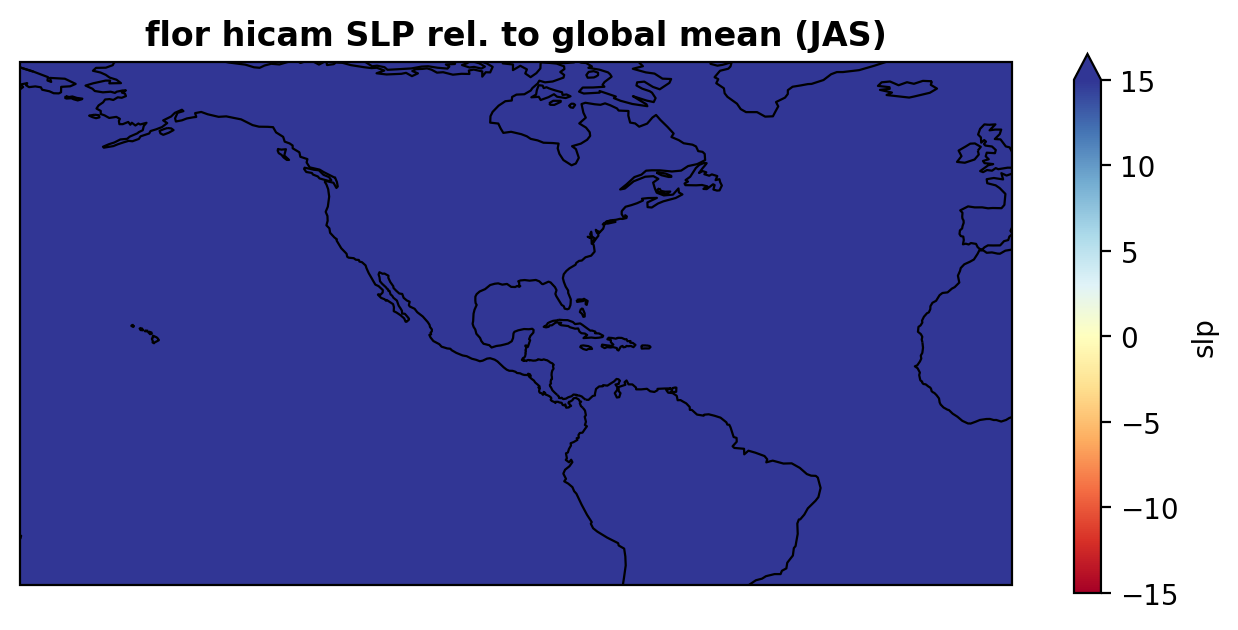

In [15]:
fig = plt.figure(figsize=(8, 5))
proj = ccrs.PlateCarree()
ax = plt.axes(projection=proj)

key='flor'
run='hicam'
varn='slp'
da=jas_mean[key][run][varn]

p = da.plot(
    ax=ax,
    vmin=-15,
    vmax=15,
    transform=ccrs.PlateCarree(),  
    cmap='RdYlBu',               
    cbar_kwargs={'shrink': 0.7, 'label': da.name if hasattr(da, 'name') else ''},
)

ax.coastlines(linewidth=0.8)
ax.set_extent([-180, 0, -25, 70], crs=ccrs.PlateCarree())
ax.set_title(f'{key} {run} SLP rel. to global mean (JAS)', fontsize=12, fontweight='bold')


### CLIMATOLOGICAL SLP/SLP ANOMALY AND LOW LEVEL WIND COMPARISON

In [ ]:
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['MERRA2', 'CTRL', r'HI$_{\mathbf{gbl}}$'])
letters=['A','B','C','D']
tx=-120.5
ty=50.25
# var specs
lat=jas_mean['flor']['ctrl']['slp'].lat
lon=jas_mean['flor']['ctrl']['slp'].lon
# vector specs
skip_nh=3
skip_nl=1
w=0.006
scalef=7
key_length=1
# bias colormap
#dcmap,_,_,_=get_settings(field='slp', diff=True)
dcmap=cm.RdYlBu #RdBu_r
dvmin=1005
dvmax=1025
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,3000,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,270,15,50]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(22,6), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'Modified Topo $-$ CTRL', **text_kw)
fig.text(0.025,0,
         'Thin black lines are model surface height boundary conditions, intervals of 500 m starting at 1 km.',
         **text_kw3)

#=== CTRL ===
cf=ax[0].pcolormesh(jas_mean['obs']['merra2']['slp'].lon, jas_mean['obs']['merra2']['slp'].lat, jas_mean['obs']['merra2']['slp'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q1=ax[0].quiver(jas_mean['obs']['merra2']['u925'].lon[::skip_nh], jas_mean['obs']['merra2']['u925'].lat[::skip_nh],
                jas_mean['obs']['merra2']['u925'][::skip_nh,::skip_nh], jas_mean['obs']['merra2']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[0].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[0].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== CTRL ===
cf=ax[1].pcolormesh(lon, lat, jas_mean['flor']['ctrl']['slp'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q1=ax[1].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['ctrl']['u925'][::skip_nh,::skip_nh], jas_mean['flor']['ctrl']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[1].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[1].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== HI-GBL ===
ax[2].pcolormesh(lon, lat, jas_mean['flor']['hitopo']['slp'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q2=ax[2].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['hitopo']['u925'][::skip_nh,::skip_nh], jas_mean['flor']['hitopo']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[2].quiverkey(q2, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[2].contour(lon, lat, topo['hitopo'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    # add box around core NAM domain
    lon_bnds = np.array([-113, -104, -104, -113])
    lat_bnds = np.array([20,  20,  34,  34])
    ring=LinearRing(list(zip(lon_bnds, lat_bnds)))
    #ax.add_geometries([ring], crs=trans, fc='none', ec='k', lw=3, linestyle='--', zorder=11) 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-131, ty+1, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=2)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=2)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=2)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# colorbar
cax=fig.add_axes([1.01, 0.15, 0.025, 0.7])
cbar=fig.colorbar(cf, ticks=np.linspace(1005,1025,11), orientation='vertical', extend='both', cax=cax)
cbar.set_label('SLP [hPa]', labelpad=25, rotation=270, size=18, fontweight='normal', ha='center') #Zonal Mean Anomaly 
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{opath}/slp.flor.e3.nam-change.{season}.pdf', transparent=False, bbox_inches='tight')

In [ ]:
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['MERRA2', 'CTRL', r'HI$_{\mathbf{gbl}}$'])
letters=['A','B','C','D']
tx=-120.5
ty=50.25
# var specs
lat=jas_mean['flor']['ctrl']['slp'].lat
lon=jas_mean['flor']['ctrl']['slp'].lon
# vector specs
skip_nh=3
skip_nl=1
w=0.006
scalef=7
key_length=1
# bias colormap
#dcmap,_,_,_=get_settings(field='slp', diff=True)
dcmap=cm.RdBu
dvmin=-10
dvmax=10
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,3000,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,270,15,50]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(22,6), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'Modified Topo $-$ CTRL', **text_kw)
fig.text(0.025,0,
         'Thin black lines are model surface height boundary conditions, intervals of 500 m starting at 1 km.',
         **text_kw3)

#=== CTRL ===
cf=ax[0].pcolormesh(jas_mean['obs']['merra2']['slpa'].lon, jas_mean['obs']['merra2']['slpa'].lat, jas_mean['obs']['merra2']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q1=ax[0].quiver(jas_mean['obs']['merra2']['u925'].lon[::skip_nh], jas_mean['obs']['merra2']['u925'].lat[::skip_nh],
                jas_mean['obs']['merra2']['u925'][::skip_nh,::skip_nh], jas_mean['obs']['merra2']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[0].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[0].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== CTRL ===
cf=ax[1].pcolormesh(lon, lat, jas_mean['flor']['ctrl']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q1=ax[1].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['ctrl']['u925'][::skip_nh,::skip_nh], jas_mean['flor']['ctrl']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[1].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[1].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== HI-GBL ===
ax[2].pcolormesh(lon, lat, jas_mean['flor']['hitopo']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q2=ax[2].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['hitopo']['u925'][::skip_nh,::skip_nh], jas_mean['flor']['hitopo']['v925'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[2].quiverkey(q2, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[2].contour(lon, lat, topo['hitopo'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    # add box around core NAM domain
    lon_bnds = np.array([-113, -104, -104, -113])
    lat_bnds = np.array([20,  20,  34,  34])
    ring=LinearRing(list(zip(lon_bnds, lat_bnds)))
    #ax.add_geometries([ring], crs=trans, fc='none', ec='k', lw=3, linestyle='--', zorder=11) 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-131, ty+1, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=2)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=2)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=2)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# colorbar
cax=fig.add_axes([1.01, 0.15, 0.025, 0.7])
cbar=fig.colorbar(cf, ticks=np.linspace(-10,10,11), orientation='vertical', extend='both', cax=cax)
cbar.set_label('SLP Anomaly rel. to Global Mean [hPa]', labelpad=25, rotation=270, size=18, fontweight='normal', ha='center') #Zonal Mean Anomaly 
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{opath}/slp.flor.e3.nam-change.{season}.pdf', transparent=False, bbox_inches='tight')

### DISTRIBUTION COMPARISON

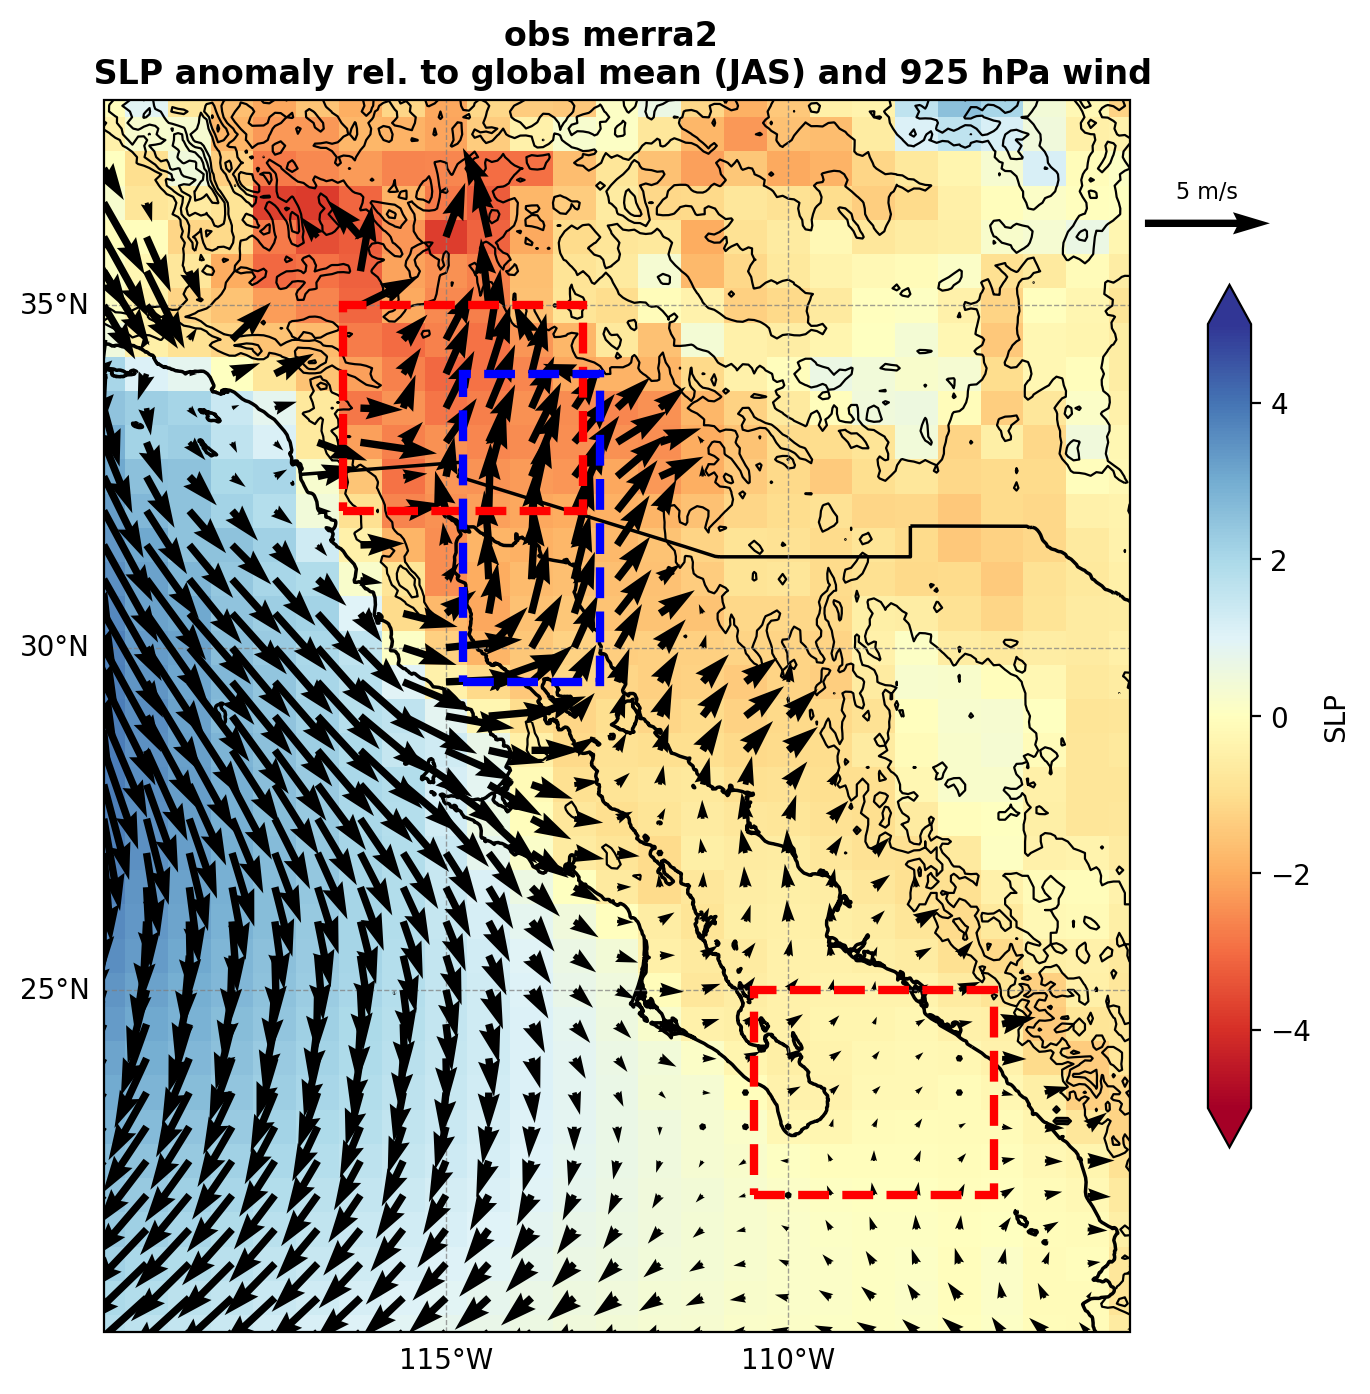

In [13]:
## !!! ask chatgpt how to do angled box selections?

# vector specs
skip_nh=1
w=0.006
scalef=8
key_length=5
# topography contours
zlevels=np.linspace(1000,4000,5)
# init fig
fig = plt.figure(figsize=(10, 8))
proj = ccrs.PlateCarree()
ax = plt.axes(projection=proj)

key='obs'
run='merra2'
varn='slpa'
da=jas_mean[key][run][varn]

p = da.plot(
    ax=ax,
    vmin=-5,
    vmax=5,
    transform=ccrs.PlateCarree(),  
    cmap='RdYlBu',               
    cbar_kwargs={'shrink': 0.7, 'label': da.name if hasattr(da, 'name') else ''},
)

# add topography
ax.contour(topo['etopo'].lon, topo['etopo'].lat, topo['etopo'], levels=zlevels, linewidths=0.8, colors='black', transform=trans)

# add wind vectors
q1=ax.quiver(jas_mean['obs']['merra2']['u925'].lon[::skip_nh], jas_mean['obs']['merra2']['u925'].lat[::skip_nh],
             jas_mean['obs']['merra2']['u925'][::skip_nh,::skip_nh], jas_mean['obs']['merra2']['v925'][::skip_nh,::skip_nh],
             color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax.quiverkey(q1, 1.075, .9, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='N', fontproperties={'size':8})

# low-lying deserts box
box=patches.Rectangle( (243.5, 32), 3.5, 3, lw=3, ls='--', ec='r', fc='none', zorder=100, transform=trans); ax.add_patch(box)
# mouth of gulf of california box
box=patches.Rectangle( (249.5, 22), 3.5, 3, lw=3, ls='--', ec='r', fc='none', zorder=100, transform=trans); ax.add_patch(box)
# GoCLLJ box
box=patches.Rectangle( (245.25, 29.5), 2, 4.5, lw=3, ls='--', ec='b', fc='none', zorder=100, transform=trans); ax.add_patch(box)

ax.set_title(f'{key} {run} \n SLP anomaly rel. to global mean (JAS) and 925 hPa wind', fontsize=12, fontweight='bold')

ax.coastlines(linewidth=1.25)
ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax.set_extent([-120, -105, 20, 38], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.75, linestyle='--')
gl.top_labels = False; gl.right_labels = False
gl.xlocator = plt.FixedLocator(range(-180, 181, 5))
gl.ylocator = plt.FixedLocator(range(-90, 91, 5))

In [13]:
slp_dsrt_bnds = [243.5, 247, 32, 35] 
slp_sgoc_bnds = [249.5, 253, 22, 25]
v925_llj_bnds = [245.25, 247.25, 29.5, 34]

mons=[7,8,9]

# !!!! will need to update to do lat-weighted mean?
# slpa
slp_dsrt = { 'merra2':{}, 'ctrl':{}, 'hicam':{}, 'hitopo':{} } 
slp_sgoc = { 'merra2':{}, 'ctrl':{}, 'hicam':{}, 'hitopo':{} }
slp_diff = { 'merra2':{}, 'ctrl':{}, 'hicam':{}, 'hitopo':{} }
v_llj = { 'merra2':{}, 'ctrl':{}, 'hicam':{}, 'hitopo':{} }

for key in ['obs','flor']:
    if key == 'obs':
        for run in ['merra2']:
            # extract just JAS months
            slpa_jas = dat[key][run]['slpa'].sel(time=dat[key][run]['slpa']['time'].dt.month.isin(mons))
            v_jas = dat[key][run]['v925'].sel(time=dat[key][run]['v925']['time'].dt.month.isin(mons))
            # average over bounding boxes
            lat_min = 32 ; lat_max = 35 ; lon_min = 243.5 ; lon_max = 247
            slp_dsrt[run] = slpa_jas.sel(lat=slice(lat_min,lat_max), lon=slice(lon_min,lon_max)).mean(dim=['lat','lon'])
            lat_min = 22 ; lat_max = 25; lon_min = 249.5 ; lon_max = 253
            slp_sgoc[run] = slpa_jas.sel(lat=slice(lat_min,lat_max), lon=slice(lon_min,lon_max)).mean(dim=['lat','lon'])
            lat_min = 29.5 ; lat_max = 34; lon_min = 245.25 ; lon_max = 247.25
            v_llj[run] = v_jas.sel(lat=slice(lat_min,lat_max), lon=slice(lon_min,lon_max)).mean(dim=['lat','lon'])
            # calculate slp difference
            slp_diff[run] = slp_sgoc[run] - slp_dsrt[run]
    elif key == 'flor':
        for run in ['ctrl','hicam','hitopo']:
            # extract just JAS months
            slpa_jas = dat[key][run]['slpa'].sel(time=dat[key][run]['slpa']['time'].dt.month.isin(mons))
            v_jas = dat[key][run]['v925'].sel(time=dat[key][run]['v925']['time'].dt.month.isin(mons))
            # average over bounding boxes
            lat_min = 32 ; lat_max = 35 ; lon_min = 243.5 ; lon_max = 247
            slp_dsrt[run] = slpa_jas.sel(lat=slice(lat_min,lat_max), lon=slice(lon_min,lon_max)).mean(dim=['lat','lon'])
            lat_min = 22 ; lat_max = 25; lon_min = 249.5 ; lon_max = 253
            slp_sgoc[run] = slpa_jas.sel(lat=slice(lat_min,lat_max), lon=slice(lon_min,lon_max)).mean(dim=['lat','lon'])
            lat_min = 29.5 ; lat_max = 34; lon_min = 245.25 ; lon_max = 247.25
            v_llj[run] = v_jas.sel(lat=slice(lat_min,lat_max), lon=slice(lon_min,lon_max)).mean(dim=['lat','lon'])
            # calculate slp difference
            slp_diff[run] = slp_sgoc[run] - slp_dsrt[run]
    else:
        pass
    
# create dataframes
slp_df = pd.concat(
    {model: da.to_series() for model, da in slp_diff.items()},
    axis=1
)

llj_df = pd.concat(
    {model: da.to_series() for model, da in v_llj.items()},
    axis=1
)

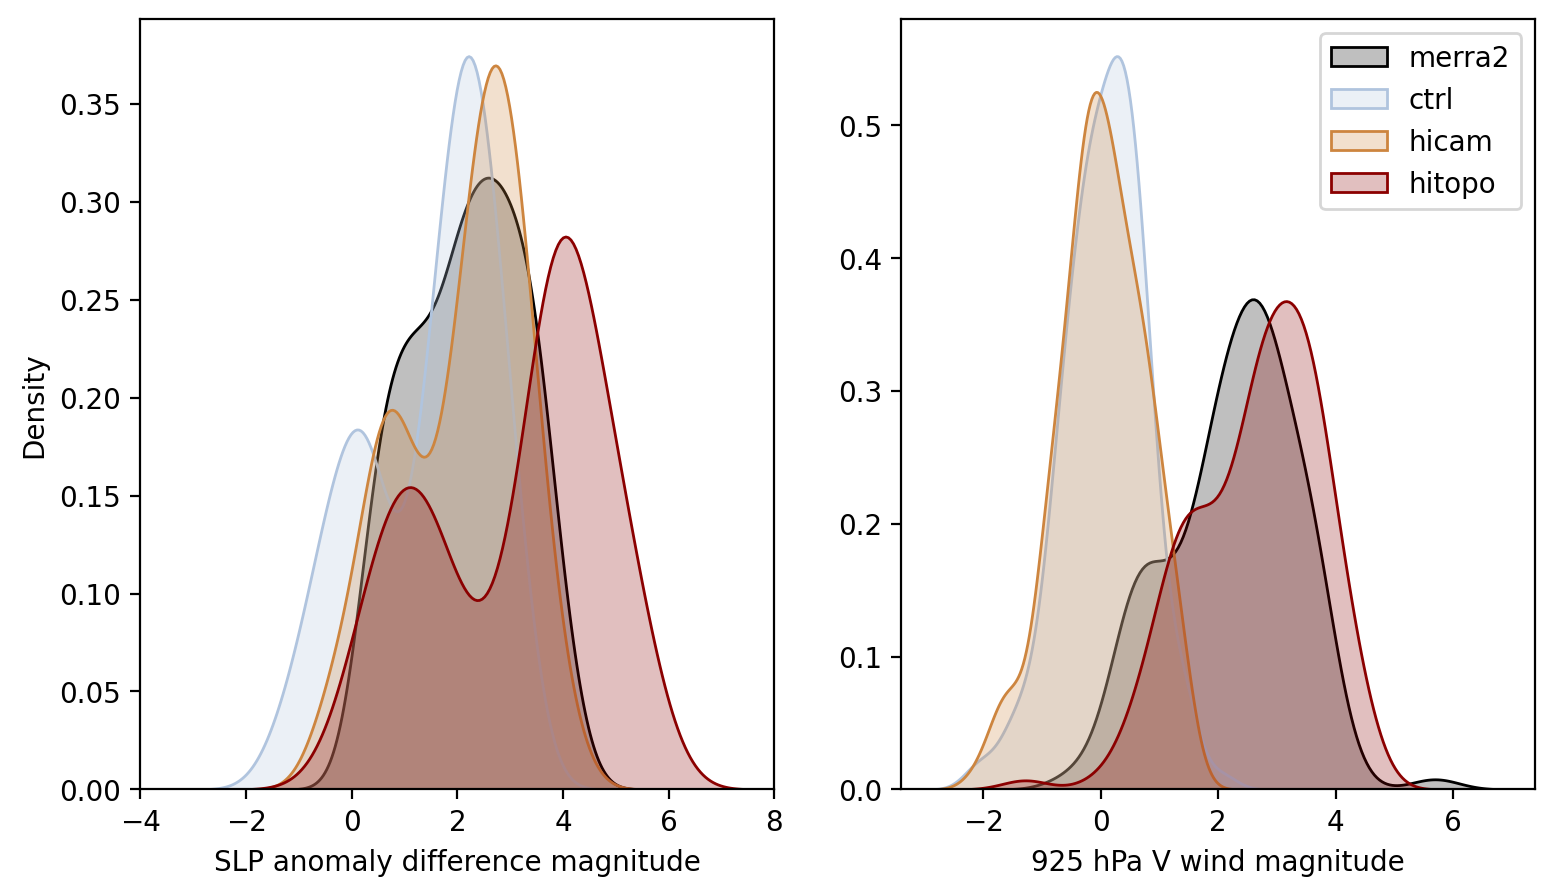

In [14]:
colors = ['black','lightsteelblue','peru','darkred']
f, ax = plt.subplots(ncols=2, figsize=(9,5))

for col, c in zip(slp_df.columns, colors):
    sns.kdeplot(
        data=slp_df[col],
        ax=ax[0],
        fill=True,
        color=c,
        label=col
    )
ax[0].set_xlabel('SLP anomaly difference magnitude')
ax[0].set(xlim=[-4,8])

for col, c in zip(llj_df.columns, colors):
    sns.kdeplot(
        data=llj_df[col],
        ax=ax[1],
        fill=True,
        color=c,
        label=col
    )
ax[1].set_xlabel('925 hPa V wind magnitude')
ax[1].set_ylabel(' ')
#ax[1].set(xlim=[-4,8])
ax[1].legend()


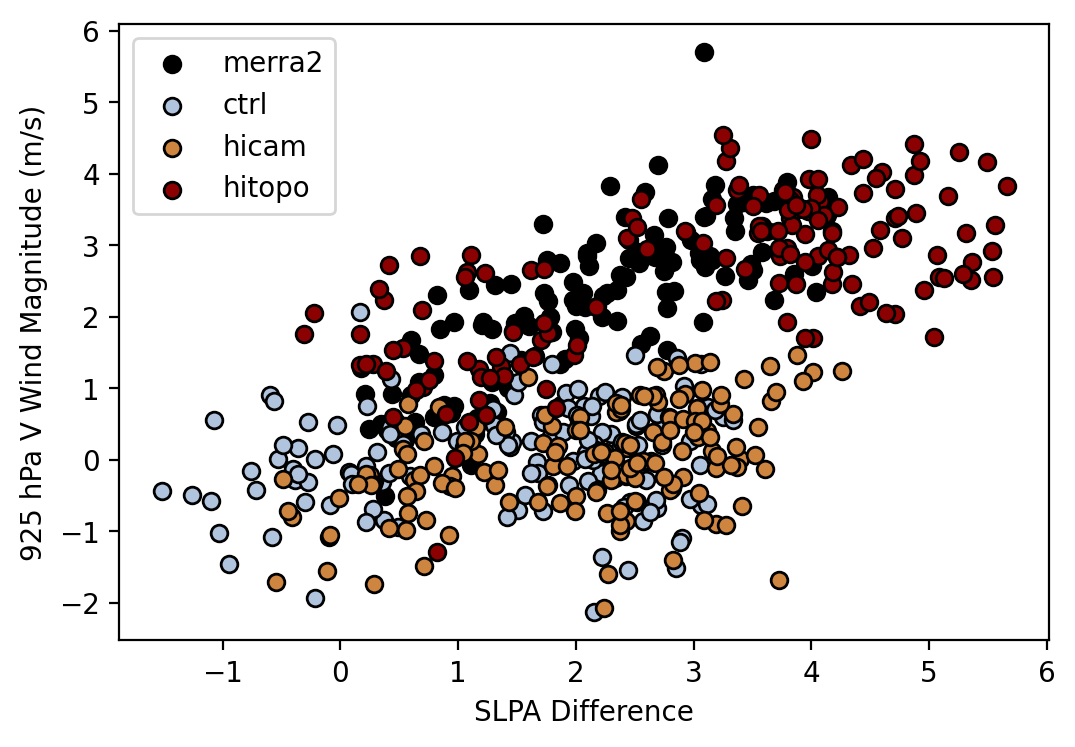

In [15]:
colors = ['black','lightsteelblue','peru','darkred']
# init fig
fig = plt.figure(figsize=(6,4))
ax = plt.axes()

for i,run in enumerate(['merra2','ctrl','hicam','hitopo']):
    ax.scatter(slp_diff[run], v_llj[run], ec='k', fc=colors[i], label=run)
ax.set_xlabel('SLPA Difference')
ax.set_ylabel('925 hPa V Wind Magnitude (m/s)')
ax.legend()

### SLP CHANGE COMPARISON

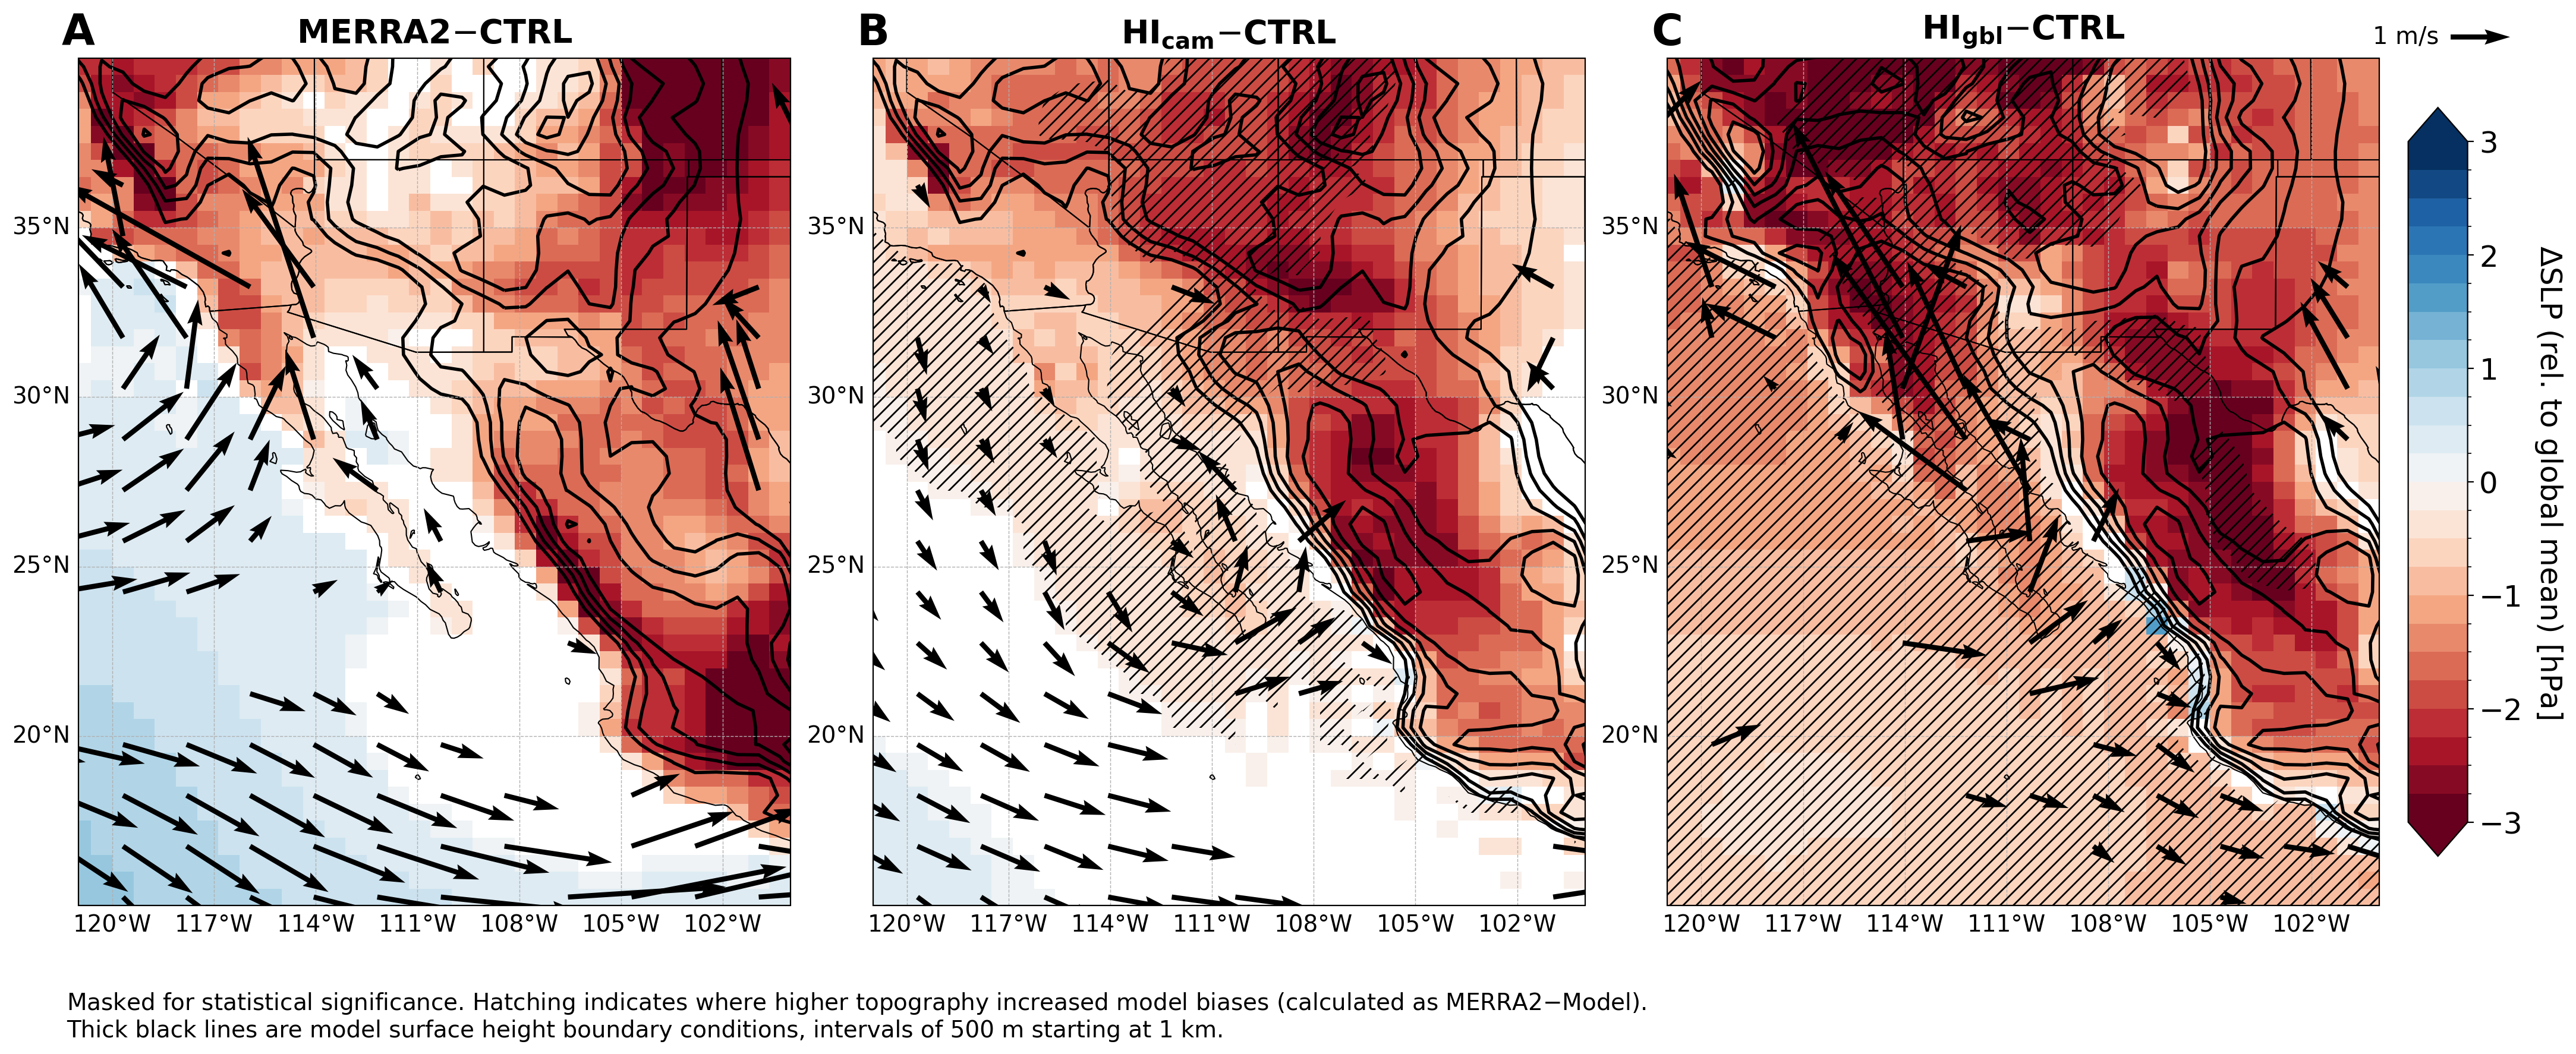

In [11]:
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array([r'MERRA2$-$CTRL', r'HI$_{\mathbf{cam}}$$-$CTRL', r'HI$_{\mathbf{gbl}}$$-$CTRL'])
letters=['A','B','C','D']
tx=-110.5
ty=40.25
# var specs
lat=jas_mean['flor']['ctrl']['slp'].lat
lon=jas_mean['flor']['ctrl']['slp'].lon
# vector specs
skip_nh=3
skip_nl=1
w=0.006
scalef=2
key_length=1
# bias colormap
#dcmap,_,_,_=get_settings(field='slp', diff=True)
dcmap=cm.RdBu
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,3000,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,9), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'Modified Topo $-$ CTRL', **text_kw)
fig.text(0.025,0,
         'Masked for statistical significance. Hatching indicates where higher topography increased model biases (calculated as MERRA2$-$Model).\n'
         'Thick black lines are model surface height boundary conditions, intervals of 500 m starting at 1 km.',
         **text_kw3)

#=== CTRL ===
cf=ax[0].pcolormesh(lon, lat, obs_diff_mask['flor']['ctrl']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)

# add wind vectors
q1=ax[0].quiver(lon[::skip_nh], lat[::skip_nh],
                obs_usig['flor']['ctrl'][::skip_nh,::skip_nh], obs_vsig['flor']['ctrl'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
#qk=ax[0].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[0].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=2, colors='black', transform=trans)

#=== HI-CAM ===
ax[1].pcolormesh(lon, lat, model_diff_mask['flor']['hicam']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q2=ax[1].quiver(lon[::skip_nh], lat[::skip_nh],
                model_usig['flor']['hicam'].squeeze()[::skip_nh,::skip_nh], model_vsig['flor']['hicam'].squeeze()[::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
#qk=ax[1].quiverkey(q2, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add hatching where bias got worse
ax[1].contourf(lon, lat, bias_change_masked['flor']['hicam']['slpa'],
               0, colors='none', hatches=['','///'], extend='lower', zorder=100, transform=trans)
# add topo contours
ax[1].contour(lon, lat, topo['hicam'], levels=zlevels, linewidths=2, colors='black', transform=trans)

#=== HI-GBL ===
ax[2].pcolormesh(lon, lat, model_diff_mask['flor']['hitopo']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q2=ax[2].quiver(lon[::skip_nh], lat[::skip_nh],
                model_usig['flor']['hitopo'].squeeze()[::skip_nh,::skip_nh], model_vsig['flor']['hitopo'].squeeze()[::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[2].quiverkey(q2, 1.1, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add hatching where bias got worse
ax[2].contourf(lon, lat, bias_change_masked['flor']['hitopo']['slpa'],
               0, colors='none', hatches=['','///'], extend='lower', zorder=100, transform=trans)
# add topo contours
ax[2].contour(lon, lat, topo['hitopo'], levels=zlevels, linewidths=2, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    # add box around core NAM domain
    lon_bnds = np.array([-113, -104, -104, -113])
    lat_bnds = np.array([20,  20,  34,  34])
    ring=LinearRing(list(zip(lon_bnds, lat_bnds)))
    #ax.add_geometries([ring], crs=trans, fc='none', ec='k', lw=3, linestyle='--', zorder=11) 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-121, ty+0.5, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=.75)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=.75)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=.75)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# colorbar
cax=fig.add_axes([1.01, 0.15, 0.025, 0.7])
cbar=fig.colorbar(cf, ticks=np.linspace(-10,10,21), orientation='vertical', extend='both', cax=cax)
cbar.set_label('$\Delta$SLP (rel. to global mean) [hPa]', labelpad=25, rotation=270, size=18, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{opath}/slp.925wind.change.flor.{season}.pdf', transparent=False, bbox_inches='tight')

### MAIN PAPER FIGURE - MAPS & DISTRIBUTIONS

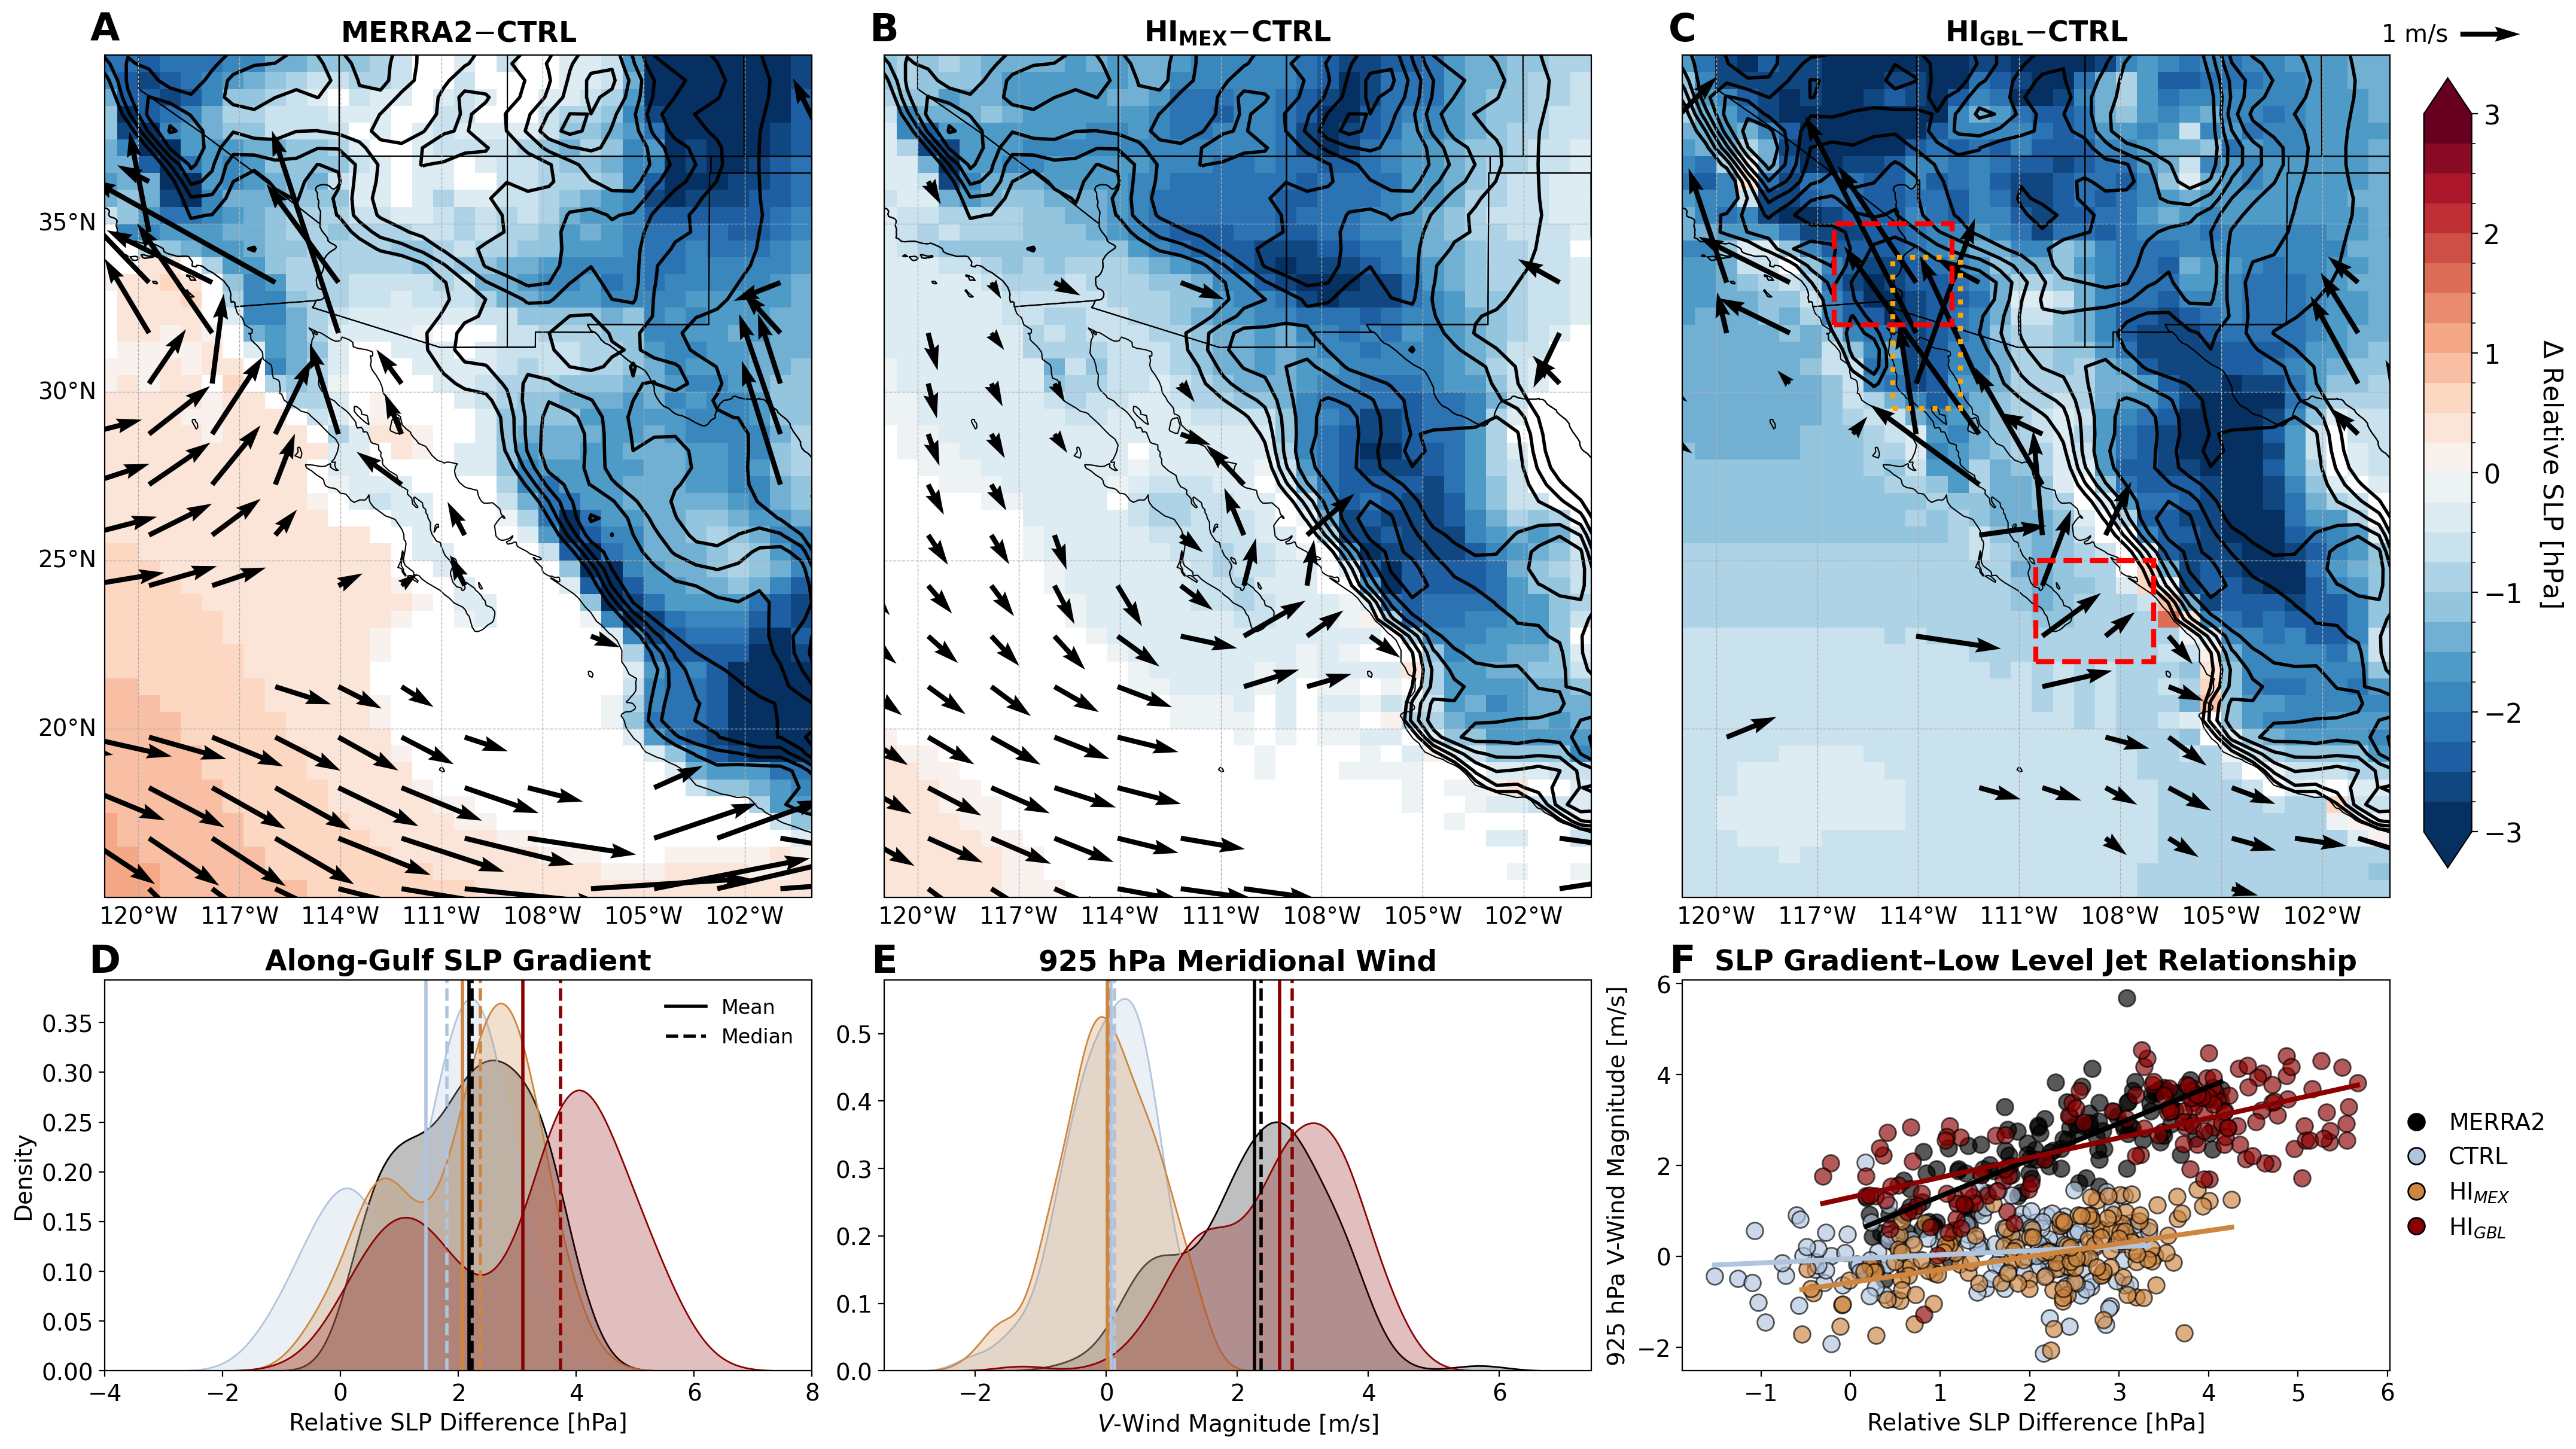

In [18]:
text_kw={'color':'k', 'weight':'bold', 'size':17, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':23, 'ha':'center', 'va':'center'}
runs = ['MERRA2', 'CTRL', 'HI$_{MEX}$', 'HI$_{GBL}$']
map_titles=[r'MERRA2$-$CTRL', r'HI$_{\mathbf{MEX}}$$-$CTRL', r'HI$_{\mathbf{GBL}}$$-$CTRL']
bottom_titles = [ 'Along-Gulf SLP Gradient', '925 hPa Meridional Wind', 'SLP Gradient–Low Level Jet Relationship']
letters=['A','B','C','D','E','F']
tx=-110.5
ty=40.25
# var specs
lat=jas_mean['flor']['ctrl']['slp'].lat
lon=jas_mean['flor']['ctrl']['slp'].lon
# vector specs
skip_nh=3
skip_nl=1
w=0.006
scalef=2
key_length=1
# distribution colors
colors = ['black','lightsteelblue','peru','darkred']
# bias colormap
dcmap=cm.RdBu_r
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,3000,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]


fig = plt.figure(figsize=(20, 12), constrained_layout=True)
gs = gridspec.GridSpec(nrows=2, ncols=3, height_ratios=[2.2, 1], figure=fig)
# define axes explicitly
ax_map = [
    fig.add_subplot(gs[0, 0], projection=proj),
    fig.add_subplot(gs[0, 1], projection=proj),
    fig.add_subplot(gs[0, 2], projection=proj),
]
ax_kde_slp = fig.add_subplot(gs[1, 0])
ax_kde_llj = fig.add_subplot(gs[1, 1])
ax_scatter = fig.add_subplot(gs[1, 2])


#=== CTRL ===
ax = ax_map[0]
cf=ax.pcolormesh(lon, lat, obs_diff_mask['flor']['ctrl']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)
q1=ax.quiver(lon[::skip_nh], lat[::skip_nh],
                obs_usig['flor']['ctrl'][::skip_nh,::skip_nh], obs_vsig['flor']['ctrl'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
ax.contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=2, colors='black', transform=trans)

#=== HI-CAM ===
ax = ax_map[1]
ax.pcolormesh(lon, lat, model_diff_mask['flor']['hicam']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)
q2=ax.quiver(lon[::skip_nh], lat[::skip_nh],
                model_usig['flor']['hicam'].squeeze()[::skip_nh,::skip_nh], model_vsig['flor']['hicam'].squeeze()[::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
#ax.contourf(lon, lat, bias_change_masked['flor']['hicam']['slpa'],
#               0, colors='none', hatches=['','///'], extend='lower', zorder=100, transform=trans)
ax.contour(lon, lat, topo['hicam'], levels=zlevels, linewidths=2, colors='black', transform=trans)

#=== HI-GBL ===
ax = ax_map[2]
ax.pcolormesh(lon, lat, model_diff_mask['flor']['hitopo']['slpa'], cmap=dcmap, norm=dnorm, transform=trans)
q2=ax.quiver(lon[::skip_nh], lat[::skip_nh],
                model_usig['flor']['hitopo'].squeeze()[::skip_nh,::skip_nh], model_vsig['flor']['hitopo'].squeeze()[::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax.quiverkey(q2, 1.1, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
#ax.contourf(lon, lat, bias_change_masked['flor']['hitopo']['slpa'],
#               0, colors='none', hatches=['','///'], extend='lower', zorder=100, transform=trans)
ax.contour(lon, lat, topo['hitopo'], levels=zlevels, linewidths=2, colors='black', transform=trans)
# low-lying deserts box
box=patches.Rectangle( (243.5, 32), 3.5, 3, lw=3, ls='--', ec='r', fc='none', zorder=100, transform=trans); ax.add_patch(box)
# mouth of gulf of california box
box=patches.Rectangle( (249.5, 22), 3.5, 3, lw=3, ls='--', ec='r', fc='none', zorder=100, transform=trans); ax.add_patch(box)
# GoCLLJ box
box=patches.Rectangle( (245.25, 29.5), 2, 4.5, lw=3, ls=':', ec='orange', fc='none', zorder=100, transform=trans); ax.add_patch(box)


for i, ax in enumerate(ax_map): 
    """
    # add box around core NAM domain
    lon_bnds = np.array([-113, -104, -104, -113])
    lat_bnds = np.array([20,  20,  34,  34])
    ring=LinearRing(list(zip(lon_bnds, lat_bnds)))
    ax.add_geometries([ring], crs=trans, fc='none', ec='k', lw=3, linestyle='--', zorder=11) 
    """
    # subplot labels
    ax.text(tx, ty, map_titles[i], **text_kw)
    ax.text(-121, ty+0.5, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=.75)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=.75)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=.75)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.left_labels = (i == 0); gl.bottom_labels = True; gl.top_labels = False; gl.right_labels = False
    gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

#=== SLP KDE ===
for col, c in zip(slp_df.columns, colors):
    vals = slp_df[col].dropna()
    sns.kdeplot(
        data=vals,
        ax=ax_kde_slp,
        fill=True,
        color=c,
        label=col
    )
    ax_kde_slp.axvline(vals.mean(), color=c, lw=2)
    ax_kde_slp.axvline(vals.median(), color=c, lw=2, ls='--')
ax_kde_slp.set_xlabel('Relative SLP Difference [hPa]', fontsize=14)
ax_kde_slp.set_ylabel('Density', fontsize=14)
ax_kde_slp.set_xlim([-4, 8])
ax_kde_slp.set_title('D', loc='left', **text_kw2)

#=== LLJ KDE ===
for col, c in zip(llj_df.columns, colors):
    vals = llj_df[col].dropna()
    sns.kdeplot(
        data=vals,
        ax=ax_kde_llj,
        fill=True,
        color=c,
        label=col
    )
    ax_kde_llj.axvline(vals.mean(), color=c, lw=2)
    ax_kde_llj.axvline(vals.median(), color=c, lw=2, ls='--')
ax_kde_llj.set_xlabel('$V$-Wind Magnitude [m/s]', fontsize=14)
ax_kde_llj.set_ylabel('')
ax_kde_llj.set_title('E', loc='left', **text_kw2)

stat_handles = [
    Line2D([0], [0], color='k', lw=2, ls='-',  label='Mean'),
    Line2D([0], [0], color='k', lw=2, ls='--', label='Median'),
]
ax_kde_slp.legend(
    handles=stat_handles,
    loc='upper right',
    frameon=False,
    fontsize=12
)

#=== SLP-LLJ Scatter ===
for i, run in enumerate(['merra2','ctrl','hicam','hitopo']):
    x = slp_diff[run]
    y = v_llj[run]
    ax_scatter.scatter(
        x,y,
        100,
        ec='k',
        fc=colors[i],
        alpha=0.65,
        label=run
    )
    # linear trend
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax_scatter.plot(
        xx,
        m * xx + b,
        color=colors[i],
        lw=3
    )
ax_scatter.set_xlabel('Relative SLP Difference [hPa]', fontsize=14)
ax_scatter.set_ylabel('925 hPa V-Wind Magnitude [m/s]', fontsize=14)
ax_scatter.set_title('F', loc='left', **text_kw2)

for ax, title in zip([ax_kde_slp, ax_kde_llj, ax_scatter], bottom_titles):
    ax.text(0.5, 1.01, title, transform=ax.transAxes, **text_kw)
for ax in [ax_kde_slp, ax_kde_llj, ax_scatter]:
    ax.tick_params(which='major', labelsize=14)

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=c,
        markeredgecolor='k',
        markersize=10,
        label=run
    )
    for run, c in zip(runs, colors)
]

fig.legend(handles=legend_handles, handletextpad=0.4, loc='center right', ncol=1, frameon=False, fontsize=14, bbox_to_anchor=(1.25, 0.5), bbox_transform=ax_scatter.transAxes)

# colorbar
cax=fig.add_axes([1.01, 0.4, 0.02, 0.55])
cbar=fig.colorbar(cf, ticks=np.linspace(-10,10,21), orientation='vertical', extend='both', cax=cax)
cbar.set_label('$\Delta$ Relative SLP [hPa]', labelpad=25, rotation=270, size=16, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=16)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

plt.savefig(f'figs/slpa.925wind.change.flor.{season}.pdf', transparent=False, bbox_inches='tight')
plt.savefig(f'figs/slpa.925wind.change.flor.{season}.png', transparent=False, bbox_inches='tight')